In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


Custom Neural Network Weights & Biases Initialization from Scratch

In [3]:
def initialize_parameters(input_dim, hidden_dim, output_dim):
    np.random.seed(42)
    W1 = np.random.randn(hidden_dim, input_dim) * 0.01
    b1 = np.zeros((hidden_dim, 1))
    W2 = np.random.randn(output_dim, hidden_dim) * 0.01
    b2 = np.zeros((output_dim, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


The Forward Propagation Pipeline Engine

In [4]:
def forward_propagation(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    return {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}, A2


The Backpropagation Calculus Engine

In [5]:
def backpropagation(X, y, cache, parameters):
    m = X.shape[1]

    W2 = parameters["W2"]
    A1 = cache["A1"]
    A2 = cache["A2"]
    Z1 = cache["Z1"]

    dZ2 = A2 - y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}


The Parameter Update Routine

In [6]:
def update_parameters(parameters, grads, learning_rate):
    W1 = parameters["W"]
    b1 = parameters["b"]
    W2 = parameters["W"]
    b2 = parameters["b"]

    dW1 = grads["dW"]
    db1 = grads["db"]
    dW2 = grads["dW"]
    db2 = grads["db"]

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


The Complete Model Training & Loss Curve Optimization Engine

In [8]:
def update_parameters(parameters, grads, learning_rate):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    dW1 = grads["dW1"]
    db1 = grads["db1"]
    dW2 = grads["dW2"]
    db2 = grads["db2"]

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


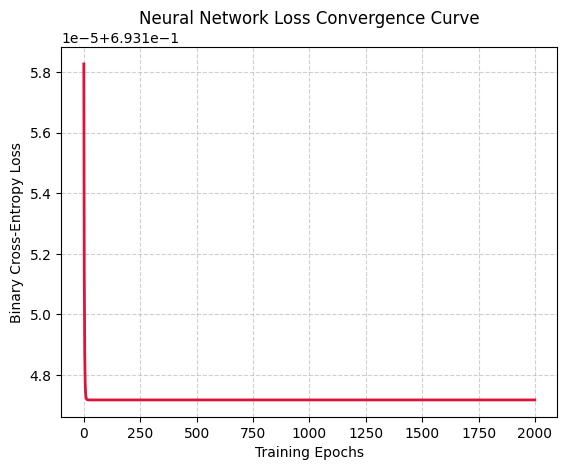

In [9]:
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T
y_train = np.array([[0, 1, 1, 0]])

input_nodes = 2
hidden_nodes = 3
output_nodes = 1
epochs = 2000
learning_rate = 0.5

params = initialize_parameters(input_nodes, hidden_nodes, output_nodes)
loss_history = []

for epoch in range(epochs):
    cache, predictions = forward_propagation(X_train, params)

    loss = -np.mean(y_train * np.log(predictions) + (1 - y_train) * np.log(1 - predictions))
    loss_history.append(loss)

    gradients = backpropagation(X_train, y_train, cache, params)
    params = update_parameters(params, gradients, learning_rate)

plt.plot(range(epochs), loss_history, color='crimson', linewidth=2)
plt.title("Neural Network Loss Convergence Curve")
plt.xlabel("Training Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
